In [56]:
import matplotlib.pyplot as plt
import numpy as np
import random
from timeskip_diffuser.diffuser.nets import EqNet, TemporalUNet
from timeskip_diffuser.diffuser.trainer import DiffuserTrainer
from timeskip_diffuser.diffuser.diffusion import GaussianDiffusion
from timeskip_diffuser.diffuser.planner import DiffuserPlanner, expand_spline_from_skip_list
from timeskip_diffuser.diffuser.reward import CompositeReward, GoalReachingReward, PathLengthPenalty, StartReachingReward, TotalTimeSkipPenalty, CurvaturePenalty, LogSkipReward
from timeskip_diffuser.datasets.point_maze.offline_skip.offline_skip import OfflineSkipDataset
import torch

In [57]:
dataset = OfflineSkipDataset(file_path="C:\\Users\\ianh\\Documents\\Code\\rpmml\\rpmml-project\\timeskip-diffuser\\src\\timeskip_diffuser\\datasets\\offline_datasets\\medium_h32_mu1_sig1.npz", dataset_id="D4RL/pointmaze/medium-v2", horizon=160)

In [58]:
len(dataset)

395375

In [59]:
net_type = "eqnet"

match net_type:
    case "eqnet":
        net_class = EqNet
        ckpt = "C:\\Users\\ianh\\Documents\\Code\\rpmml\\rpmml-project\\timeskip-diffuser\\src\\timeskip_diffuser\\pipelines\\runs\\medium_eqnet_skip_seed0_20251221_131741\\checkpoints\\diffuser_eqnet_epoch_20.pt"
    case "unet":
        net_class = TemporalUNet
        ckpt = "..."

In [60]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = net_class(
    state_dim=dataset.state_dim+1,
    time_dim=32,
)
diffusion = GaussianDiffusion(timesteps=200)
trainer = DiffuserTrainer(model, diffusion, dataset, lr=1e-4, device=device)
trainer.load_checkpoint(ckpt)
planner = DiffuserPlanner(model, diffusion, dataset, device=device)

Using device: cuda


(32, 2)
(32, 1)


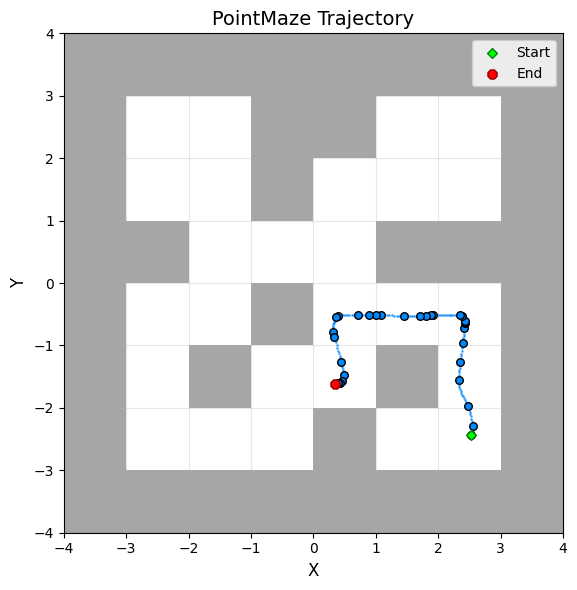

In [61]:
traj_norm = random.choice(dataset)
traj = dataset.denormalize(traj_norm)
dataset.visualize(traj)

In [128]:
current = np.array([1.5, -2.5]) # traj[0][:2].copy()
goal = np.array([-2, 2]) # traj[-1][:2].copy()
print(current, goal)

[ 1.5 -2.5] [-2  2]


In [135]:
reward_fn = CompositeReward([
        StartReachingReward(current, reward_scale=5.0),
        GoalReachingReward(goal, reward_scale=5.0),
        TotalTimeSkipPenalty(reward_scale=0.0001),
        CurvaturePenalty(reward_scale=0.01),
        LogSkipReward(reward_scale=0.0),
])

traj_model = planner.plan_and_reconstruct(
    current,
    goal,
    reward_fn=reward_fn,
    horizon=64,
    guidance_scale=1.0,
    condition_on_start=True,
    condition_on_goal=True,
    conditioning_schedule="constant",
    conditioning_strength=0.9,
    spline_func=expand_spline_from_skip_list,
)["coarse"]
print(traj_model)
print(f"Start (actual): {traj_model[0, :2]}")
print(f"Start (target): {current[:2]}")
print(f"Start error: {np.linalg.norm(traj_model[0, :2] - current[:2]):.4f}")
print(f"End: {traj_model[-1, :2]}")
print(f"Goal: {goal}")
print(f"Goal error: {np.linalg.norm(traj_model[-1, :2] - goal):.4f}")

# Check for discontinuities (physics violations)
diffs = np.linalg.norm(traj_model[1:, :2] - traj_model[:-1, :2], axis=1)
max_jump = diffs.max()
print(f"Max step size: {max_jump:.4f}")
if max_jump > 0.2:  # Adjust threshold based on your maze
    print("  ⚠️  WARNING: Large discontinuity detected!")
else:
    print("  ✓ Trajectory appears continuous")

[[ 1.5959696  -2.5078576   0.233248  ]
 [ 1.5162798  -2.5132847   1.3135118 ]
 [ 1.5485892  -2.5157301   5.4358053 ]
 [ 1.5501591  -2.5449522   3.9244897 ]
 [ 1.571695   -2.5731897   3.129801  ]
 [ 1.6099132  -2.588481    1.2031648 ]
 [ 1.6363662  -2.603681    5.621063  ]
 [ 1.8210715  -2.6654506   7.358472  ]
 [ 2.1077006  -2.6796725   2.1809988 ]
 [ 2.1971114  -2.668965    2.4654188 ]
 [ 2.2877223  -2.6670594   4.049585  ]
 [ 2.389383   -2.6419902   1.6522315 ]
 [ 2.426694   -2.6154819   2.3976088 ]
 [ 2.4638352  -2.5600781   2.7344308 ]
 [ 2.484029   -2.4770226   4.502575  ]
 [ 2.4750931  -2.2840016   1.5632226 ]
 [ 2.4704745  -2.199961    0.7781942 ]
 [ 2.4760957  -2.1345725   0.9087024 ]
 [ 2.4780874  -2.0548964   6.4530635 ]
 [ 2.4570568  -1.8114634  10.479048  ]
 [ 2.4242373  -1.3796494   4.4307094 ]
 [ 2.4073186  -1.1356838   2.667221  ]
 [ 2.4069297  -0.99895954  1.8743241 ]
 [ 2.4097672  -0.9025926   1.4938908 ]
 [ 2.416367   -0.82929885 15.269182  ]
 [ 2.123117   -0.53005654

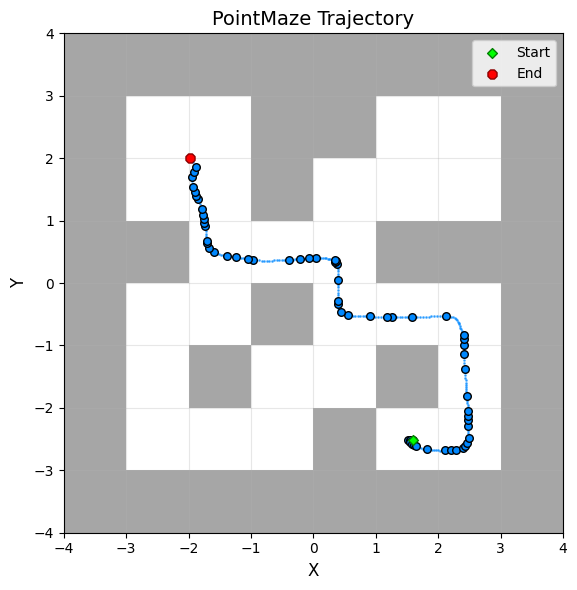

In [136]:
dataset.visualize(traj_model)

In [134]:
traj_model[:, 2].sum()

234.44293